# EXPLORATORY DATA ANALYSIS (EDA)

        

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### LOADING THE DATA

In [7]:
df= pd.read_csv(r"D:\Users\Downloads\heartdisease.csv")

### INSPECTING THE DATA

##### VIEWING FIRST 5 ROWS

In [8]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


#####  CHECKING COLUMN DATA TYPES 

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


##### Investigating Missing Values and Duplicates

In [98]:
print("Missing Values per column:\n", df.isnull().sum())

Missing Values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [102]:
print("\nNumber of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


#####  CHECKING FOR STATISTICAL SUMMARIES (MEAN, MIN, MAX etc)

In [91]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## VISUALIZING AND FINDING PATTERNS

#### Checking Target Variable balance

In [16]:
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

#### Visualizing the TARGET VARIABLE using Seaborn

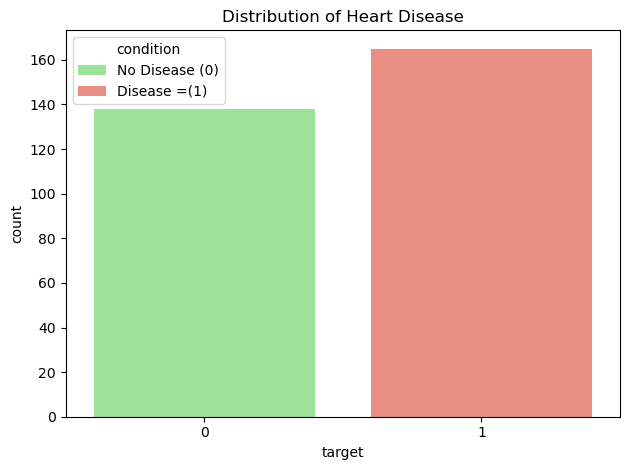

In [12]:
sns.countplot(x='target', data=df)
plt.title('Distribution of Heart Disease')
custom_colors = ["lightgreen", "salmon"]
ax= sns.countplot(x='target', hue= 'target', data=df, palette=custom_colors, legend=True)
plt.legend(title='condition', labels=['No Disease (0)', 'Disease =(1)'])
bbox_to_anchor= (1.05, 1),
loc='upper left'
plt.tight_layout();
plt.show()

#### Count of heart Disease Based on Gender

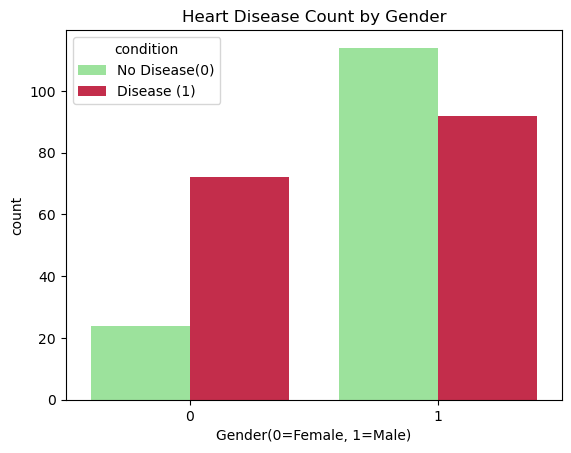

In [93]:
gender_colors= ["lightgreen", "crimson"]
sns.countplot(x='sex', hue='target', data=df, palette= gender_colors)
plt.title('Heart Disease Count by Gender')
plt.xlabel('Gender(0=Female, 1=Male)')
plt.ylabel('count')
plt.legend(title='condition', labels=['No Disease(0)', 'Disease (1)'])


#### Checking Age Distribution of Patients using a histogram

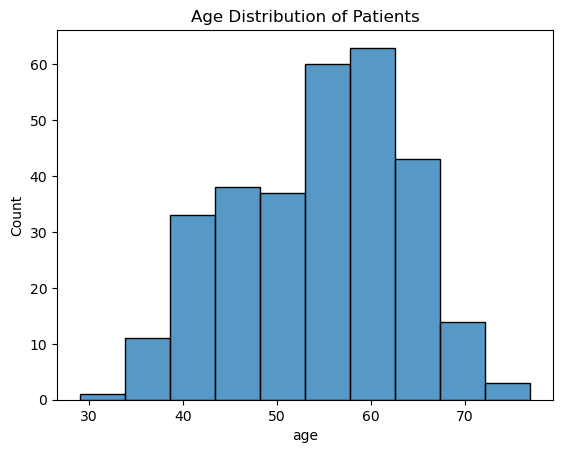

In [19]:
sns.histplot(df['age'], bins=10)
plt.title('Age Distribution of Patients');
plt.show()

#### Is Heart Disease related to Age? (Box Plot)

''

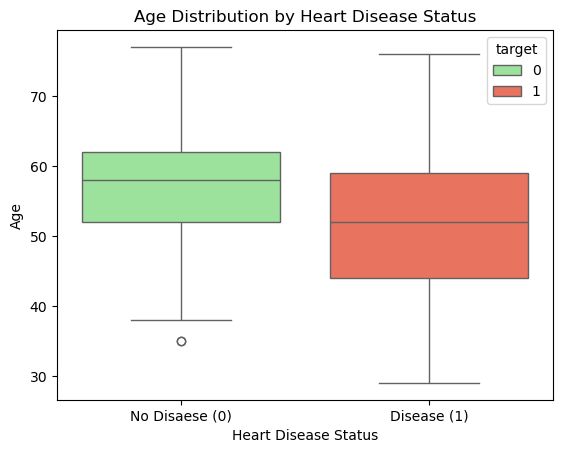

In [18]:
age_colors = ["lightgreen", "tomato"]
sns.boxplot(x='target', y='age', hue='target', data=df, palette=age_colors, legend= True)
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Heart Disease Status')
plt.ylabel('Age')
plt.xticks(ticks=[0,1], labels=['No Disaese (0)', 'Disease (1)'])
;

#### Correlation Matrix (Relationships btw target variable and other features)

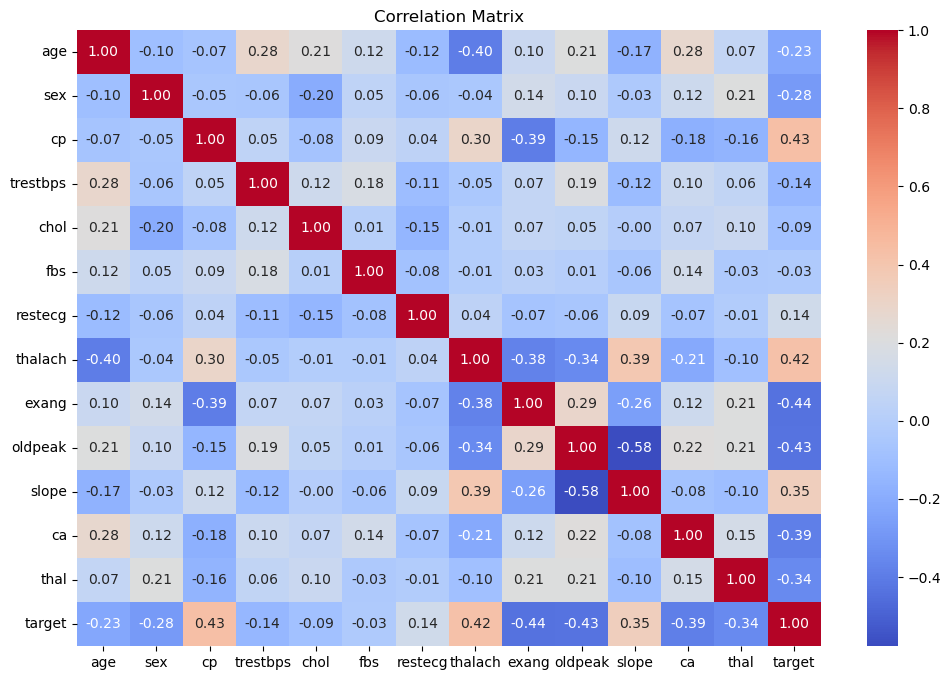

In [20]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()
